In [69]:
import pandas as pd
import os
import xarray as xr
import sys

sys.path.append('../ProcessEvents/')
from config import CATCHMENT_LOOKUP_DICT, OUT_DIR # MOLLY_DIR_FF, RAINFALL_CSV_DIR, ENSEMBLE_MEMBERS, , CATCHMENTS

### Get rainfall events

In [71]:
catchment_num = '23'
catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
rainfall_events_all = []

fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
rainfall_events = pd.read_pickle(fp)
rainfall_events_complete = rainfall_events[rainfall_events['mismatch']!=True].copy()
rainfall_events['catchment_num'] = catchment_num
# print(f"Catchment {catchment_num} has {len(rainfall_events)}, of which {len(rainfall_events) - len(rainfall_events_complete)} are mismatched")
rainfall_events_all.append(rainfall_events) 
rainfall_events_all_df = pd.concat(rainfall_events_all, ignore_index=True)    
rainfall_events_all_df.reset_index(inplace=True, drop = True)

In [73]:
# # fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments.pkl"
# # rainfall_events_all_df = pd.read_pickle(fp)
# events  = rainfall_events_all_df[rainfall_events_all_df['catchment_num'].isin(["23", '40', '105'])]
# events[['catchment_num', 'rainfall_peak_day', 'ens', 'event_num', 'month']][:15]
# events['t_global']

In [5]:
# fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments.pkl"
# rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = pd.read_csv("/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments_with_topography.csv")
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df['length'] = rainfall_events_all_df['times'].apply(len)

### Add a column which specifies what the relevant soil filename would be called for this event

In [77]:
def build_soil_filename(row):
    ens_str = f"{int(row['ens']):02d}"  # zero-pads 1 -> "01", leaves 11 -> "11"
    return (
        f"soil_{row['catchment_num']}_{row['event_num']}_"
        f"{row['start_year']}_{row['start_month']}_{row['start_day']}_Ens_{ens_str}_vol_5km.nc")

rainfall_events_all_df["soil_filename"] = rainfall_events_all_df.apply(build_soil_filename, axis=1)

### Get events which have the new soil data

In [79]:
events  = rainfall_events_all_df[rainfall_events_all_df['catchment_num'].isin(["23", '40', '105'])]

In [108]:
vol_sm_ls =[]
imd_ls = []
remaining_capacity_ls =[]

for event_num, event in events.iterrows():
    ens = str(event['ens']).zfill(2)
    catchment_num = event['catchment_num']
    nc_path = f"../../Data/SoilDynamicVariables/combined_from_tif/Ens_{ens}/nc/{catchment_num}/" + event['soil_filename']
    hc_5km = xr.open_dataset(nc_path, engine="netcdf4")
    
    # Append values to lists of values
    vol_sm_ls.append(hc_5km['vol_sm'].isel(projection_y_coordinate=int(event['y_idx']),
            projection_x_coordinate=int(event['x_idx'])).item())
    imd_ls.append(
        hc_5km['imd'].isel(projection_y_coordinate=int(event['y_idx']), projection_x_coordinate=int(event['x_idx'])).item())
    remaining_capacity_ls.append(hc_5km['remaining_capacity'].isel(projection_y_coordinate=int(event['y_idx']),
                                                                   projection_x_coordinate=int(event['x_idx'])).item())

In [110]:
events['vol_sm'] = vol_sm_ls
events['imd'] = imd_ls
events['remaining_capacity'] = remaining_capacity_ls

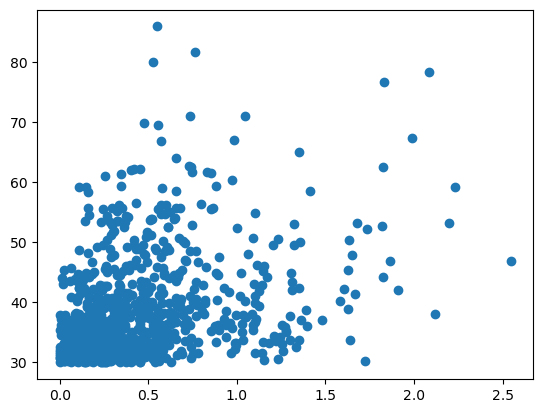

In [113]:
import matplotlib.pyplot as plt
plt.scatter(events['10cm_area'], events['max_precip']) 